### Подключение модулей

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow import keras

In [2]:
import warnings
warnings.filterwarnings('ignore')

Целью этого проекта является прогнозирование и анализ цен продажи жилья в США. Требуется построить регрессионную модель для прогнозирования цен на жилье в США на основе различных факторов.


### Загрузка данных

In [3]:
df = pd.read_csv('USA_Housing.csv')

In [4]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


Данные содержат следующие столбцы:
- __Avg. Area Income__ (Сред. Доход от района): Средний доход жителей города по региону.
- __Avg. Area House Age__ (Сред. Площадь дома): Средний возраст домов в районе.
- __Avg. Area Number of Rooms__ (Сред. Площадь Количество комнат): Среднее количество комнат в домах в том же городе.
- __Avg. Area Number of Bedrooms__ (Сред. Площадь Количество спален): Среднее количество спален в домах в том же городе.
- __Area Population__ (Население региона): Население городского дома, в котором находится.
- __Price__ (Цена): Цена, по которой был продан дом.
- __Address__ (Адрес): Адрес дома.
    

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [7]:
pd.set_option('display.float_format', lambda x: '%0.4f' % x)

In [8]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,68583.1090,5.9772,6.9878,3.9813,36163.5160,1232072.6541
std,10657.9912,0.9915,1.0058,1.2341,9925.6501,353117.6266
min,17796.6312,2.6443,3.2362,2.0000,172.6107,15938.6579
25%,61480.5624,5.3223,6.2993,3.1400,29403.9287,997577.1350
50%,68804.2864,5.9704,7.0029,4.0500,36199.4067,1232669.3780
75%,75783.3387,6.6508,7.6659,4.4900,42861.2908,1471210.2042
max,107701.7484,9.5191,10.7596,6.5000,69621.7134,2469065.5942


In [9]:
df.hist(figsize=(20,20));

In [10]:
plt.figure(figsize=(8,6))
sns.pairplot(df)

In [11]:
sns.regplot(y='Price', x='Avg. Area Income', data=df)

<Axes: xlabel='Avg. Area Income', ylabel='Price'>

In [12]:
df[['Avg. Area Income', 'Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population', 'Price']].corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.0000,-0.0020,-0.0110,0.0198,-0.0162,0.6397
Avg. Area House Age,-0.0020,1.0000,-0.0094,0.0061,-0.0187,0.4525
Avg. Area Number of Rooms,-0.0110,-0.0094,1.0000,0.4627,0.0020,0.3357
Avg. Area Number of Bedrooms,0.0198,0.0061,0.4627,1.0000,-0.0222,0.1711
Area Population,-0.0162,-0.0187,0.0020,-0.0222,1.0000,0.4086
Price,0.6397,0.4525,0.3357,0.1711,0.4086,1.0000


In [13]:
sns.heatmap(df[['Avg. Area Income', 'Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population', 'Price']].corr(), annot=True)

<Axes: >

In [14]:
df['House Age'] = df['Avg. Area House Age'].apply(int)

In [15]:
plt.figure(figsize = (12, 6), dpi = 200)
sns.barplot(x = 'House Age', y = 'Price', data = df, ci = None)

<Axes: xlabel='House Age', ylabel='Price'>

In [16]:
df['Number of Rooms'] = df['Avg. Area Number of Rooms'].apply(int)

In [17]:
plt.figure(figsize = (12, 6), dpi = 200)
sns.barplot(x = 'Number of Rooms', y = 'Price', data = df, ci = None)

<Axes: xlabel='Number of Rooms', ylabel='Price'>

In [18]:
df['Number of Bedrooms'] = df['Avg. Area Number of Bedrooms'].apply(int)

In [19]:
plt.figure(figsize = (12, 6), dpi = 200)
sns.barplot(x = 'Number of Bedrooms', y = 'Price', data = df, ci = None)

<Axes: xlabel='Number of Bedrooms', ylabel='Price'>

### Обучение модели линейной регрессии

In [20]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address',
       'House Age', 'Number of Rooms', 'Number of Bedrooms'],
      dtype='object')

In [21]:
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]

In [22]:
y = df['Price']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Линейная регрессия

In [24]:
lrm = LinearRegression()
lrm.fit(X_train, y_train)

LinearRegression()

In [25]:
lrm.intercept_

np.float64(-2638673.426191325)

In [26]:
lrm.coef_

array([2.16257989e+01, 1.65590393e+05, 1.19827783e+05, 2.36109526e+03,
       1.52165814e+01])

In [27]:
y_pred_lr = lrm.predict(X_test)

In [28]:
y_pred_lr

array([1308536.1359262 , 1237122.72746477, 1243835.62817066, ...,
       1457119.79297242, 1483428.9530937 , 1047510.59737176])

In [29]:
y_test.round(3)

1501   1339096.0770
2586   1251794.1790
2653   1340094.9660
1055   1431507.6230
705    1042373.5240
           ...     
3563   1348221.7650
1538   1309937.3990
1837   1472887.2470
2380   1409762.1190
1912   1009606.2840
Name: Price, Length: 1500, dtype: float64

In [30]:
plt.scatter(y_test, y_pred_lr)

In [31]:
sns.regplot(x=y_test,y=y_pred_lr,line_kws={"color":"black"})

<Axes: xlabel='Price', ylabel='Price'>

### Метрики оценки качества регрессии


Общие показатели оценки для задач регрессии:

**Mean Absolute Error** (MAE Средняя абсолютная ошибка) - это среднее значение абсолютного значения ошибок:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE Среднеквадратическая ошибка) - это среднее значение квадратов ошибок:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE Среднеквадратическая ошибка) - это квадратный корень из среднего квадрата ошибок:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

**Коэффициент детерминации** $R^{2}$

$$R^2 = 1 - \frac{\frac{1}{n}\sum^{n}_{i}{(y - y_{pred})^2}}{\frac{1}{n}\sum^{n}_{i}{(y - \bar{y})^2}}$$

In [32]:
mean_absolute_error(y_test, y_pred_lr)

81135.56609336875

In [33]:
mean_squared_error(y_test, y_pred_lr)

10068422551.401081

In [34]:
np.sqrt(mean_squared_error(y_test, y_pred_lr))

np.float64(100341.52954485537)

In [35]:
r2_score(y_test, y_pred_lr)

0.9146818498753999

In [36]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

### Random Forest Regression

In [37]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [38]:
rf_r2_score = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test,y_pred_rf))

print('Random Forest Regression:')
print(f'R2 Score: {rf_r2_score:.4f}')
print(f'MAE: {rf_mae:.2f}')
print(f'RMSE: {rf_rmse:.2f}')

Random Forest Regression:
R2 Score: 0.8784
MAE: 94723.76
RMSE: 119786.14


### Нейронная модель

In [39]:
X = df.drop(['Address', 'Price'], axis=1)
y = df['Price']

In [40]:
# Стандартизация данных
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()

In [41]:
model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, input_shape=(8,), activation='relu', name='input'),
        tf.keras.layers.Dense(32, activation='relu', name='hidden_1'),
        tf.keras.layers.Dense(16, activation='relu', name='hidden_2'),
        tf.keras.layers.Dense(1, name='output')
    ])

In [42]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [43]:
# Обучение
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.4225 - mae: 0.4703 - mse: 0.4225 - val_loss: 0.1137 - val_mae: 0.2698 - val_mse: 0.1137
Epoch 2/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0995 - mae: 0.2519 - mse: 0.0995 - val_loss: 0.0961 - val_mae: 0.2487 - val_mse: 0.0961
Epoch 3/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0906 - mae: 0.2427 - mse: 0.0906 - val_loss: 0.0952 - val_mae: 0.2474 - val_mse: 0.0952
Epoch 4/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0877 - mae: 0.2386 - mse: 0.0877 - val_loss: 0.0940 - val_mae: 0.2466 - val_mse: 0.0940
Epoch 5/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0841 - mae: 0.2338 - mse: 0.0841 - val_loss: 0.0966 - val_mae: 0.2489 - val_mse: 0.0966
Epoch 6/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0822 - mae: 0.2307 - mse: 0.0822 - val_loss: 0.0980 - val_mae: 0.2514 - val_mse: 0.0980
Epoch 7/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0804 - mae: 0.2272 - mse: 0.0804 - val_loss:

In [44]:
y_pred_scaled = model.predict(X_test_scaled).flatten()

y_pred_scaled

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([ 0.22184871, -0.02692495,  0.07759739, ...,  0.6006458 ,
        0.61460096, -0.49793908], dtype=float32)

In [45]:
# Обратное масштабирование цен
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

In [46]:
nn_mae = mean_absolute_error(y_test, y_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
nn_r2 = r2_score(y_test, y_pred)

print('Neural model:')
print(f'R2 Score: {nn_r2:.4f}')
print(f'MAE: {nn_mae:.2f}')
print(f'RMSE: {nn_rmse:.2f}')

Neural model:
R2 Score: 0.9071
MAE: 84671.18
RMSE: 104708.23


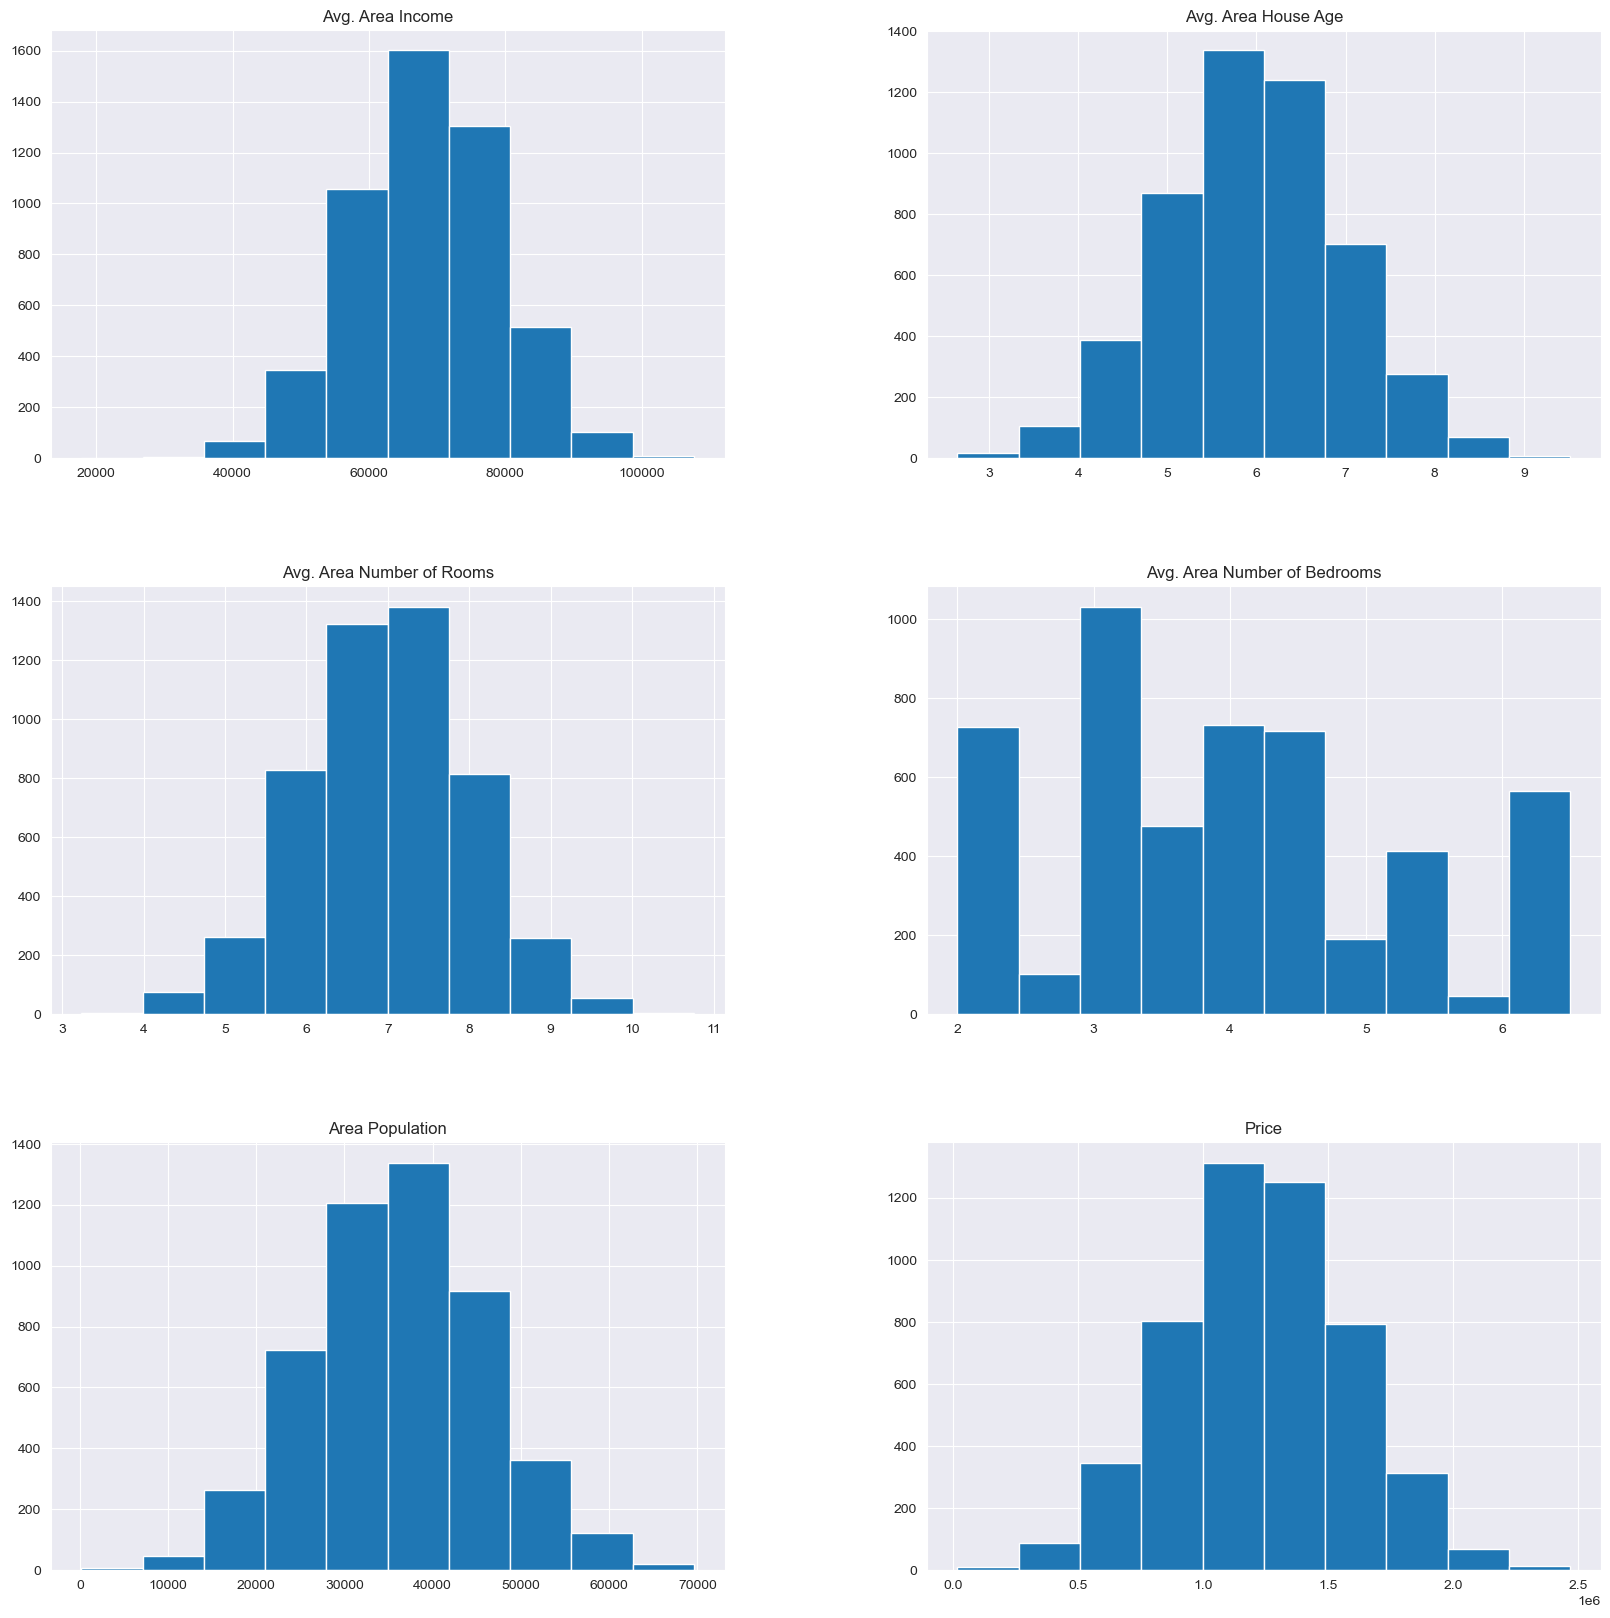

<Figure size 800x600 with 0 Axes>

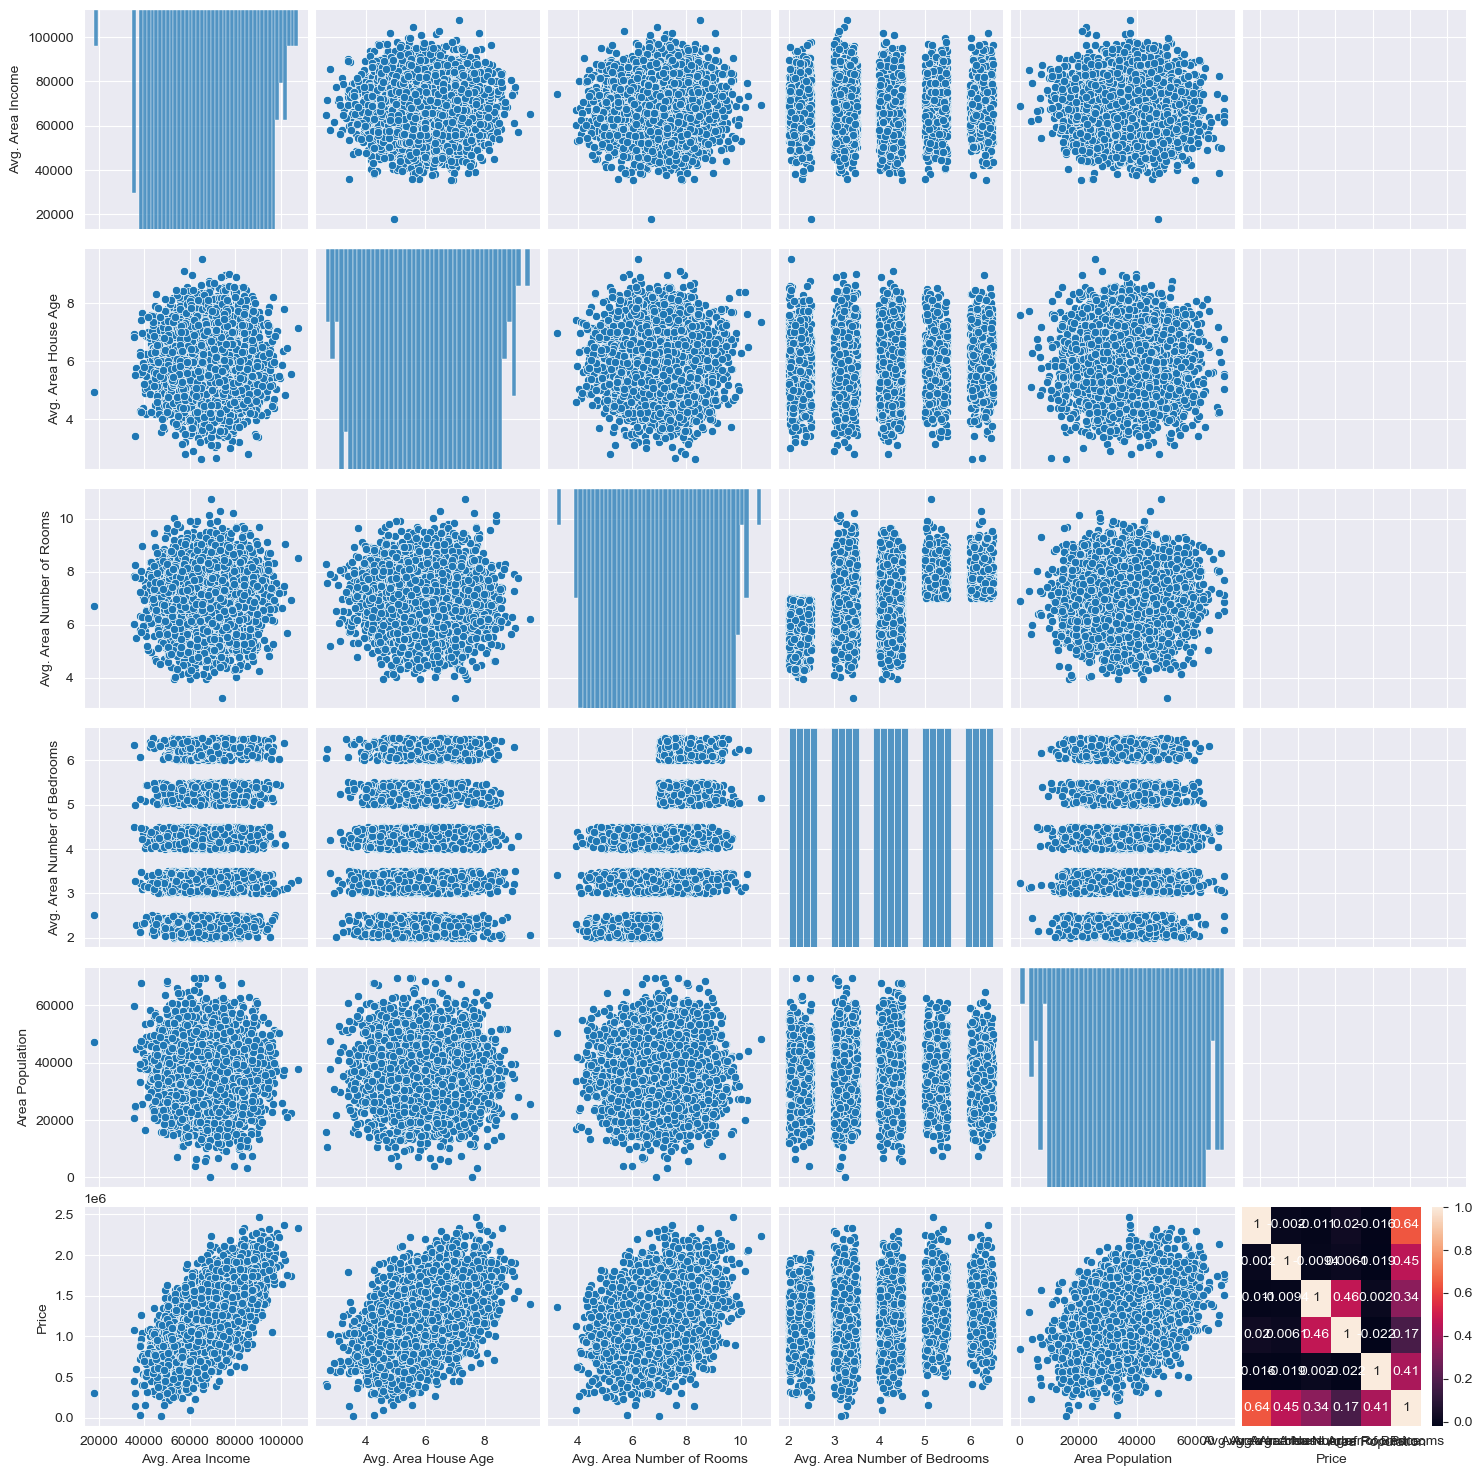

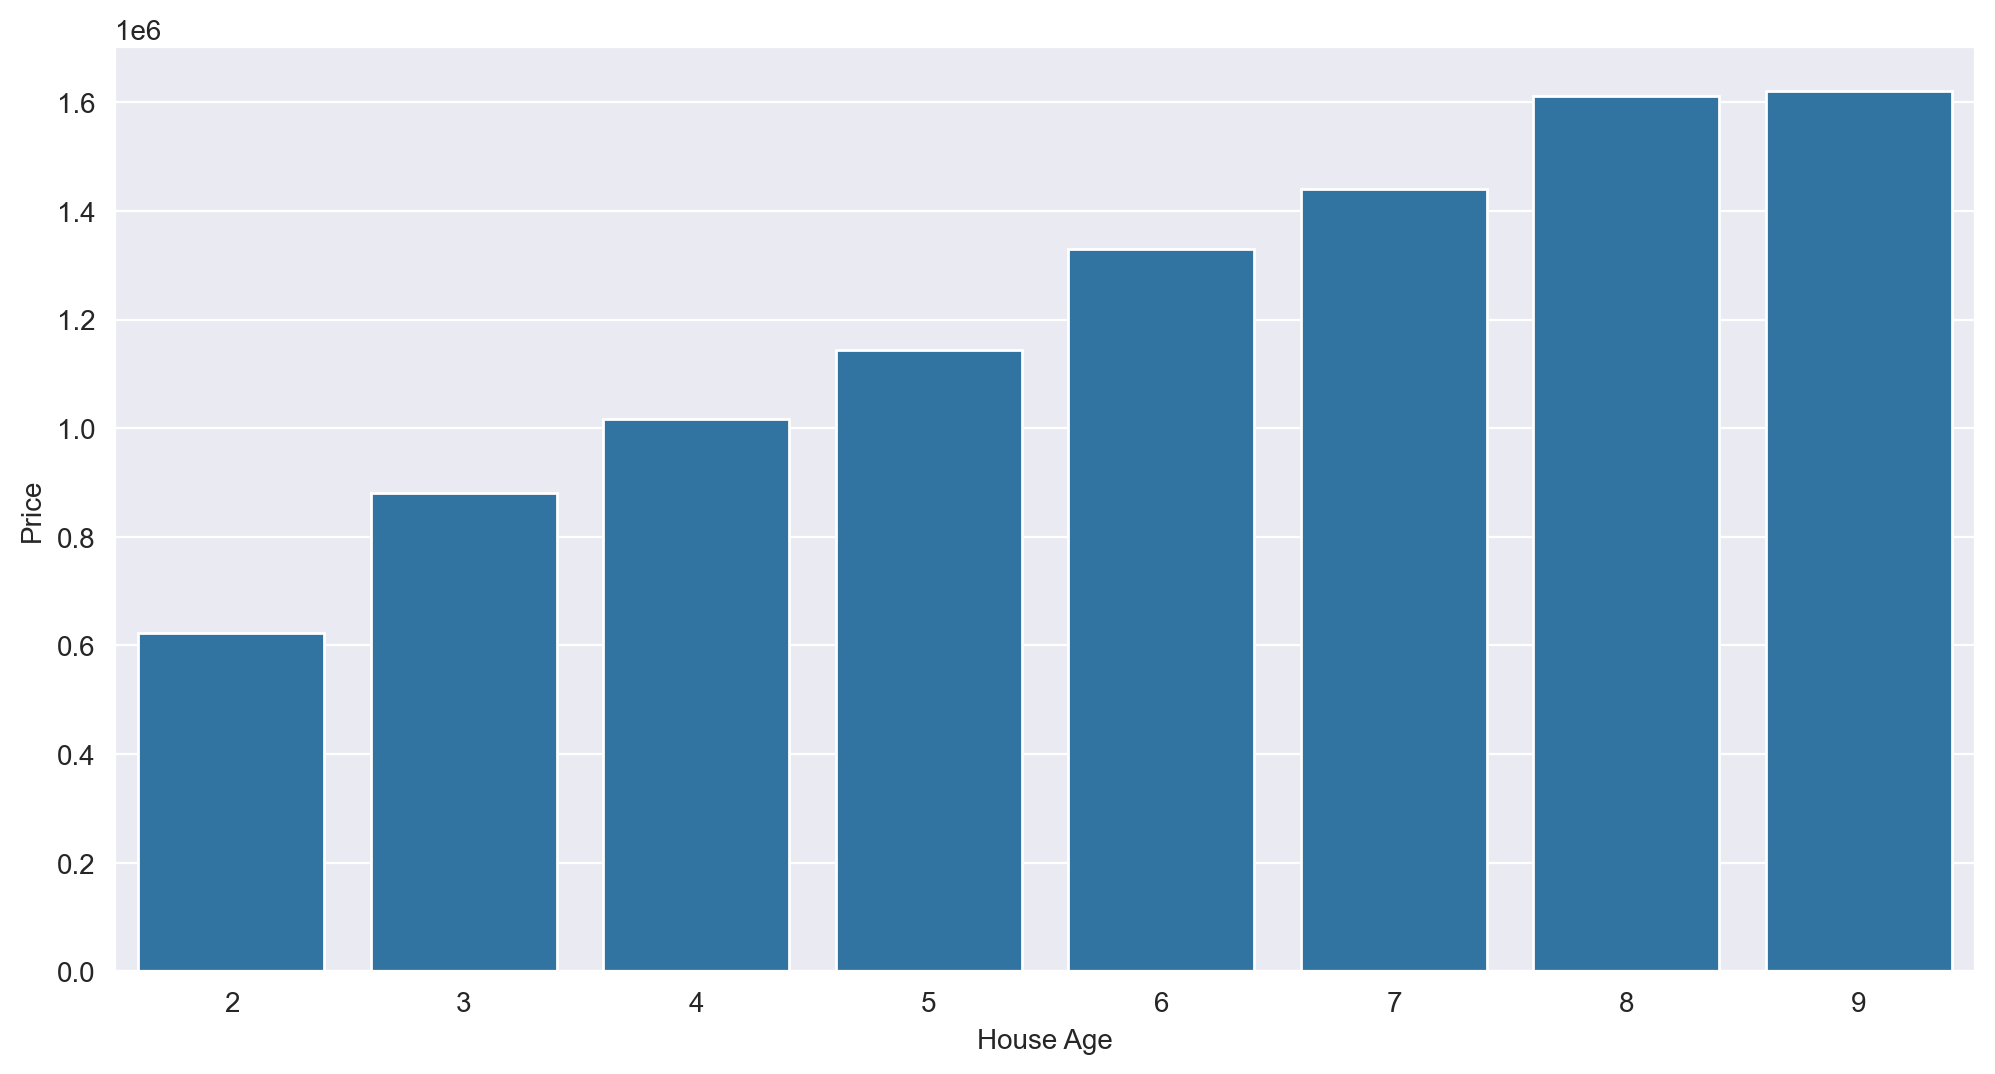

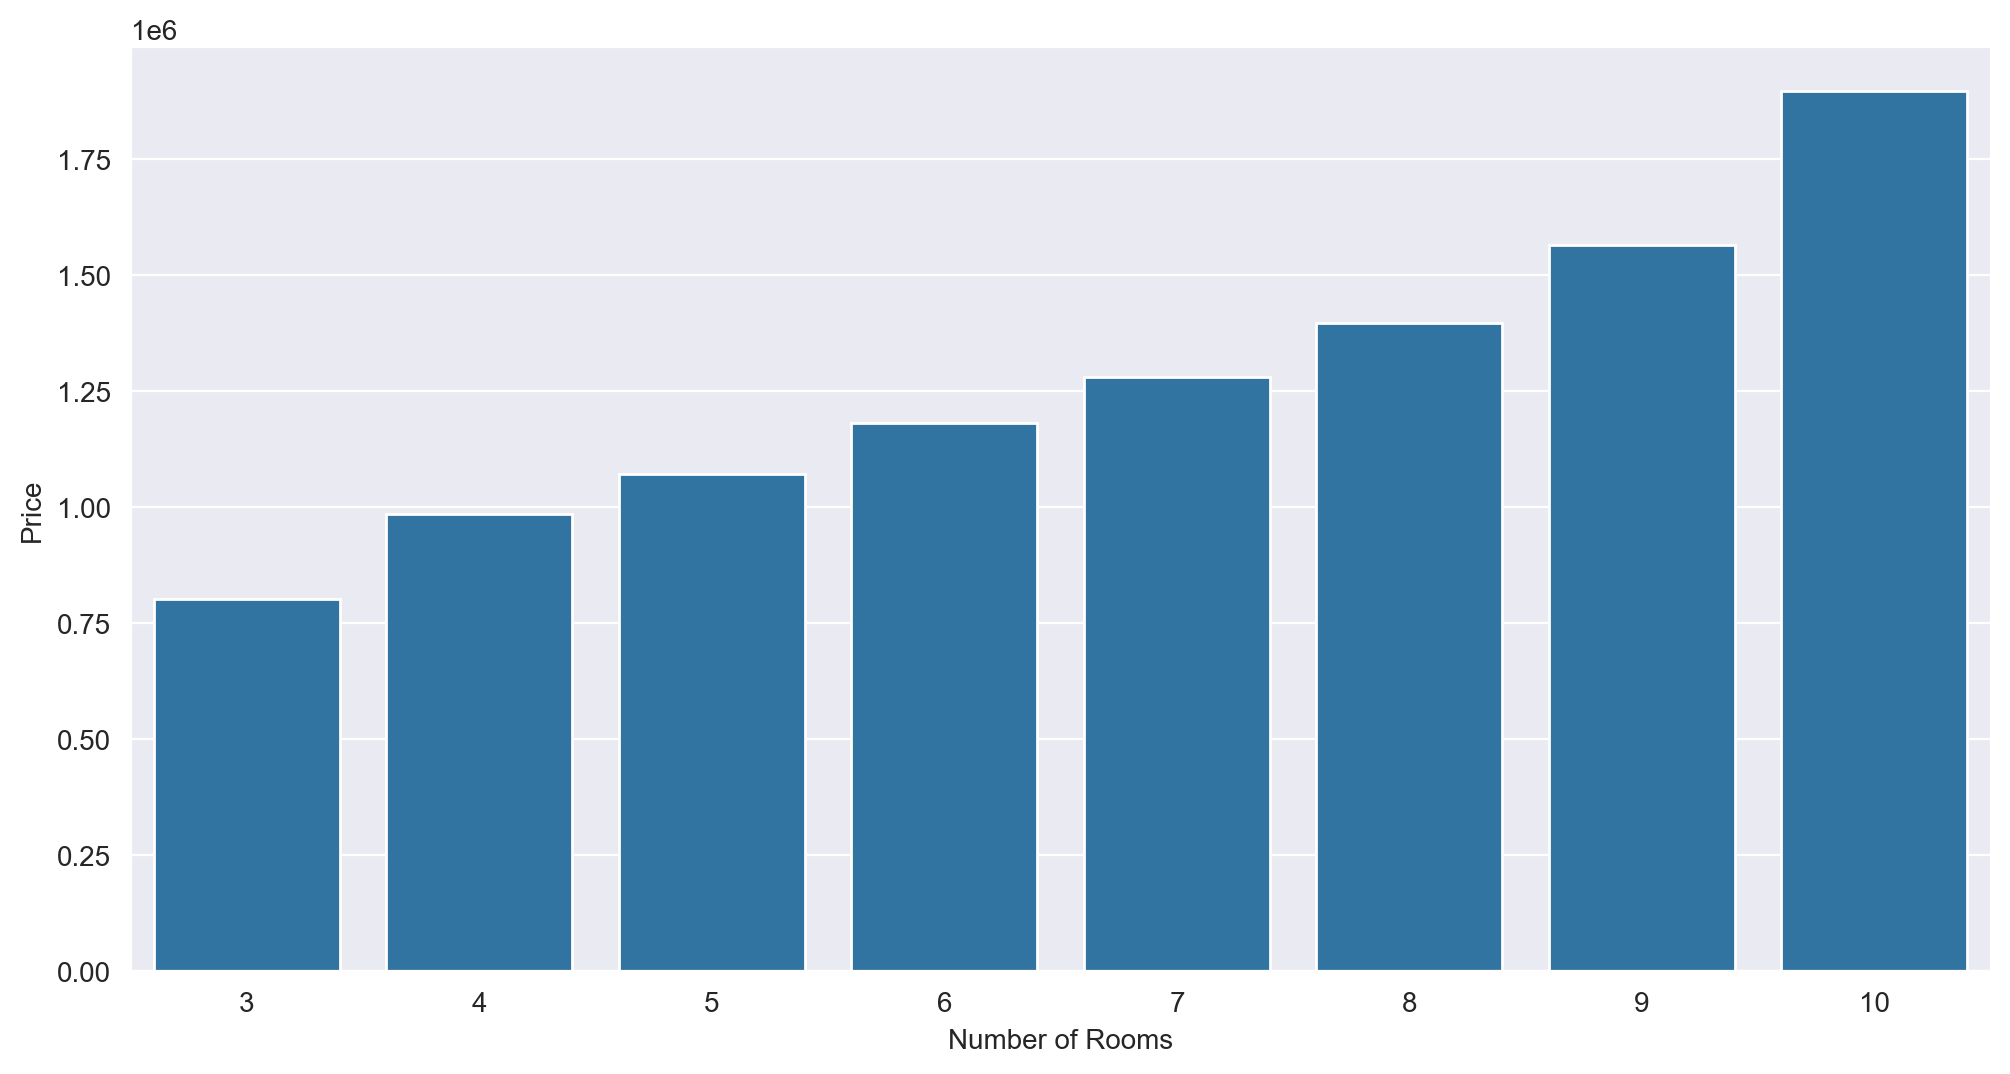

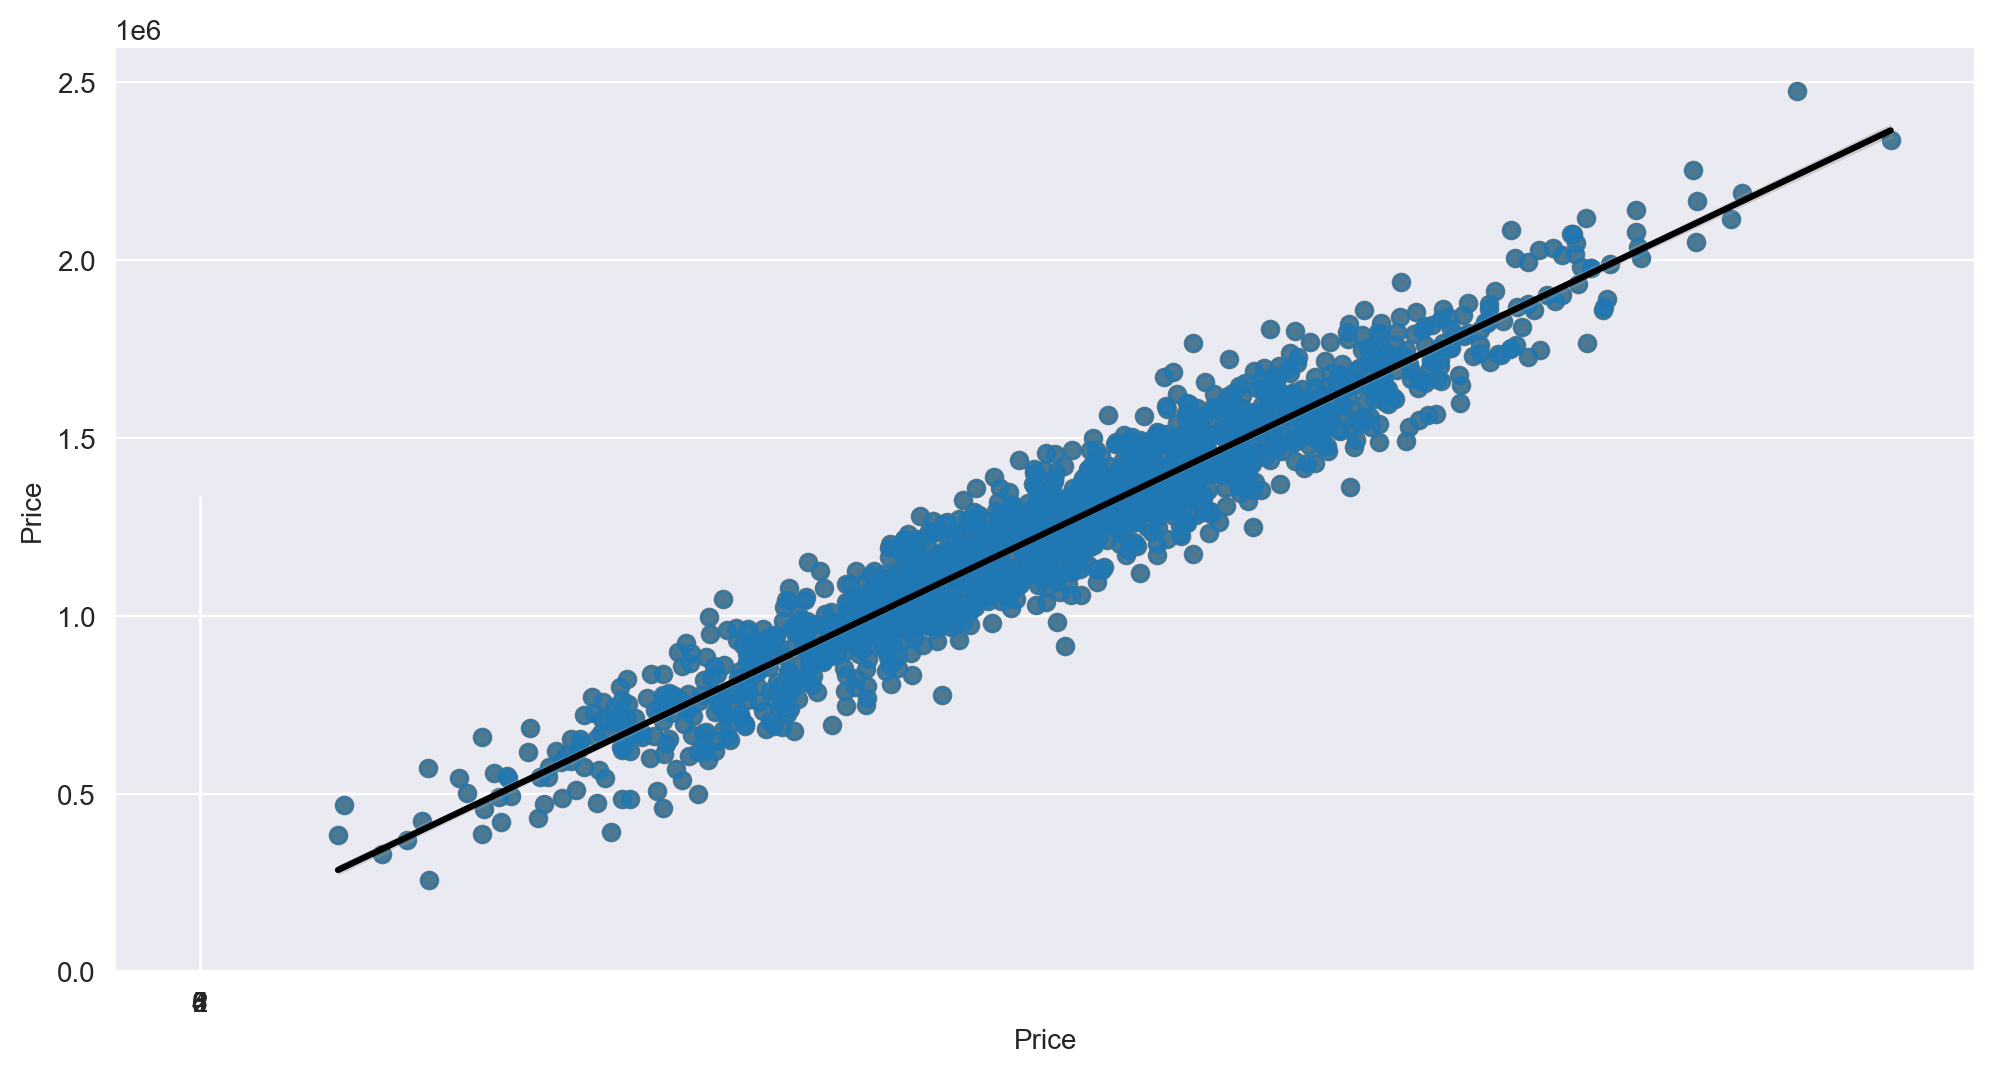

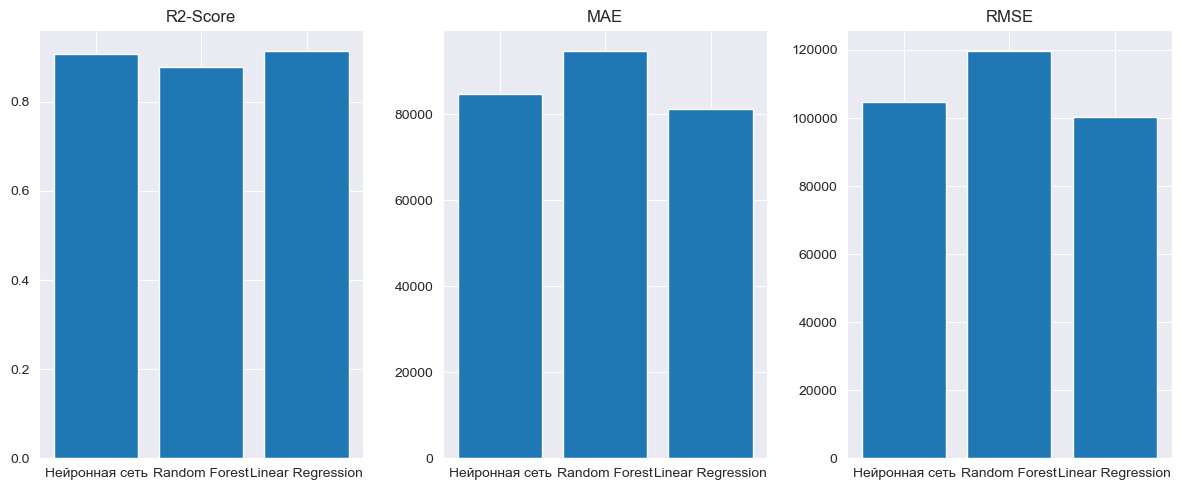

In [47]:
# Сбор метрик
results = {
    'Нейронная сеть': {
        'r2': nn_r2,
        'MAE': nn_mae,
        'RMSE': nn_rmse,
    },
    'Random Forest': {
        'r2': rf_r2_score,
        'MAE': rf_mae,
        'RMSE': rf_rmse,
    },
    'Linear Regression': {
        'r2': lr_r2,
        'MAE': lr_mae,
        'RMSE': lr_rmse,
    }
}

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# r2
r2_list = [results[model]['r2'] for model in results.keys()]
axes[0].bar(results.keys(), r2_list,)
axes[0].set_title('R2-Score')


# mae
mae_list = [results[model]['MAE'] for model in results.keys()]
axes[1].bar(results.keys(), mae_list)
axes[1].set_title('MAE')

# rmse
rmse_list = [results[model]['RMSE'] for model in results.keys()]
axes[2].bar(results.keys(), rmse_list)
axes[2].set_title('RMSE')


plt.tight_layout()
plt.show()